### LOAN PORTFOLIO MONITORING & EARLY WARNING SYSYTEM ###

BY ELMA FORTUNATE PHIRI

Aim: Track all active loans and detect early signs of financial stress before customers default. 

Goal: Build a Loan Portfolio Monitoring & Early Warning System (EWS)

Qn: Are they moving toward default

Objectives

Detect risky loans early
Monitor portfolio health
Support decision-making (who to intervene on)

IMPORTING LIBRARIES

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ydata_profiling as pp
import warnings
%matplotlib inline

warnings.filterwarnings(action= 'ignore')

In [2]:
#Importing Machine Learning Libraries 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, auc,roc_auc_score,roc_curve
import shap

In [3]:
#Data Loading
credit= pd.read_csv(r"c:\Users\My PC\Desktop\Datasets\Loan Portfolio System\Credit Risk.csv")
credit.head()

,Loan ID,Borrower Name,Branch,RM,Province,City / Town,Loan Product,Sector,Collateral Type,Issue Date,...,Collateral\nValue (USD),LTV\n(%),Revol Util\n(%),DPD,Missed\nPmts,Part\nPmts,Bank Bal\nTrend,Inflation\nExp,Forex\nIncome,Loan Status
0,CNB-010001,Tambudzai Chirwa,Kwekwe Branch,T. Chinyoka,Harare Metropolitan,Harare,School Fees Loan,Transport & logistics,Residential property,20/8/2021,...,"$2,356",74.90%,71.30%,0,2,0,Stable,High,No,Special mention
1,CNB-010002,Chipo Mahachi,Mutare Branch,T. Chinyoka,Mashonaland West,Kadoma,Salary-Backed Loan,Health & pharmaceuticals,Salary cession,8/1/2020,...,$417,40.30%,88.30%,0,1,3,Severely declining,High,No,Watch
2,CNB-010003,Rudo Taruvinga,Gweru Branch,N. Gumbo,Bulawayo Metropolitan,Bulawayo,Green Energy Loan,Transport & logistics,Motor vehicle,31/1/2023,...,"$3,221",37.40%,11.80%,0,1,1,Improving,Low,Yes,Performing
3,CNB-010004,Primrose Majoni,Harare Main,B. Makoni,Masvingo,Chiredzi,Medical Finance,Retail trade,Residential property,30/3/2022,...,$601,116.50%,22.00%,7,0,0,Improving,Medium,No,Special mention
4,CNB-010005,Dumisani Madzivire,Bulawayo Main,P. Mhlanga,Mashonaland West,Kadoma,Microfinance Loan,Construction,Equipment & machinery,14/9/2020,...,"$2,069",88.00%,38.20%,0,1,1,Stable,Medium,Yes,Performing


In [4]:
credit["Loan Status"].unique()

array(['Special mention', 'Watch', 'Performing', 'Non-performing'],
      dtype=object)

Understanding Data

In [4]:
credit.info()
credit.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Loan ID                 5000 non-null   object
 1   Borrower Name           5000 non-null   object
 2   Branch                  5000 non-null   object
 3   RM                      5000 non-null   object
 4   Province                5000 non-null   object
 5   City / Town             5000 non-null   object
 6   Loan Product            5000 non-null   object
 7   Sector                  5000 non-null   object
 8   Collateral Type         5000 non-null   object
 9   Issue Date              5000 non-null   object
 10  Maturity Date           5000 non-null   object
 11  Tenor (Mo)              5000 non-null   int64 
 12  Loan Amt
(USD)          5000 non-null   object
 13  Outstanding
(USD)       5000 non-null   object
 14  Int Rate
(%)            5000 non-null   object
 15  Annu

,Tenor (Mo),Credit\nScore,Emp Length\n(Yrs),DPD,Missed\nPmts,Part\nPmts
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.647800,577.067800,7.026600,26.418800,1.798000,1.190400
std,16.671417,152.245326,5.970747,39.971347,1.783881,1.121427
min,3.000000,280.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,449.000000,3.000000,0.000000,0.000000,0.000000
50%,18.000000,573.000000,5.000000,7.000000,1.000000,1.000000
75%,36.000000,697.000000,10.000000,45.000000,3.000000,2.000000
max,84.000000,849.000000,25.000000,180.000000,7.000000,4.000000


In [5]:
#Profile Report
pp.ProfileReport(credit)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:01<00:00, 22.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Data Cleaning

In [6]:
#Missing Variables

credit.isnull().sum()

Loan ID                      0
Borrower Name                0
Branch                       0
RM                           0
Province                     0
City / Town                  0
Loan Product                 0
Sector                       0
Collateral Type              0
Issue Date                   0
Maturity Date                0
Tenor (Mo)                   0
Loan Amt\n(USD)              0
Outstanding\n(USD)           0
Int Rate\n(%)                0
Annual Income\n(USD)         0
DTI\n(%)                     0
DSCR                         0
Credit\nScore                0
Emp Length\n(Yrs)            0
Collateral\nValue (USD)      0
LTV\n(%)                   328
Revol Util\n(%)              0
DPD                          0
Missed\nPmts                 0
Part\nPmts                   0
Bank Bal\nTrend              0
Inflation\nExp               0
Forex\nIncome                0
Loan Status                  0
dtype: int64

In [7]:
#Drop Unnecessary Columns
credit = credit.drop(columns=[
    'Loan ID',
    'Borrower Name',
    "LTV\n(%)",
     "DSCR",
      "DTI\n(%)"
])

In [8]:
#Data Types

credit.dtypes

Branch                     object
RM                         object
Province                   object
City / Town                object
Loan Product               object
Sector                     object
Collateral Type            object
Issue Date                 object
Maturity Date              object
Tenor (Mo)                  int64
Loan Amt\n(USD)            object
Outstanding\n(USD)         object
Int Rate\n(%)              object
Annual Income\n(USD)       object
Credit\nScore               int64
Emp Length\n(Yrs)           int64
Collateral\nValue (USD)    object
Revol Util\n(%)            object
DPD                         int64
Missed\nPmts                int64
Part\nPmts                  int64
Bank Bal\nTrend            object
Inflation\nExp             object
Forex\nIncome              object
Loan Status                object
dtype: object

In [11]:
credit["Province"].unique()

array(['Harare Metropolitan', 'Mashonaland West', 'Bulawayo Metropolitan',
       'Masvingo', 'Mashonaland East', 'Matabeleland South', 'Manicaland',
       'Midlands', 'Matabeleland North', 'Mashonaland Central'],
      dtype=object)

In [12]:
#Clean column names
credit.columns = credit.columns.str.replace('\n', ' ').str.strip()

In [13]:
credit.columns.tolist()

['Branch',
 'RM',
 'Province',
 'City / Town',
 'Loan Product',
 'Sector',
 'Collateral Type',
 'Issue Date',
 'Maturity Date',
 'Tenor (Mo)',
 'Loan Amt (USD)',
 'Outstanding (USD)',
 'Int Rate (%)',
 'Annual Income (USD)',
 'Credit Score',
 'Emp Length (Yrs)',
 'Collateral Value (USD)',
 'Revol Util (%)',
 'DPD',
 'Missed Pmts',
 'Part Pmts',
 'Bank Bal Trend',
 'Inflation Exp',
 'Forex Income',
 'Loan Status']

In [14]:
credit.columns = credit.columns.str.strip()

In [15]:
#Fix Data Types
credit['Issue Date'] = pd.to_datetime(credit['Issue Date'])
credit['Maturity Date'] = pd.to_datetime(credit['Maturity Date'], format='%d/%m/%Y')


### EDA ###

In [16]:
credit.shape
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Branch                  5000 non-null   object        
 1   RM                      5000 non-null   object        
 2   Province                5000 non-null   object        
 3   City / Town             5000 non-null   object        
 4   Loan Product            5000 non-null   object        
 5   Sector                  5000 non-null   object        
 6   Collateral Type         5000 non-null   object        
 7   Issue Date              5000 non-null   datetime64[ns]
 8   Maturity Date           5000 non-null   datetime64[ns]
 9   Tenor (Mo)              5000 non-null   int64         
 10  Loan Amt (USD)          5000 non-null   object        
 11  Outstanding (USD)       5000 non-null   object        
 12  Int Rate (%)            5000 non-null   object  

In [17]:
credit.columns[credit.columns.duplicated()]

Index([], dtype='object')

In [18]:
credit = credit.loc[:, ~credit.columns.duplicated()]

In [19]:
credit.columns = credit.columns.str.strip()

In [21]:
type(credit['Collateral Value (USD)'])

pandas.core.series.Series

In [22]:
cols_to_clean = ['Collateral Value (USD)', 'Loan Amt (USD)', 'Outstanding (USD)', 
                 'Annual Income (USD)', 'Revol Util (%)']
for col in cols_to_clean:
    credit[col] = pd.to_numeric(credit[col].replace('[^0-9.]', '', regex=True), errors='coerce')


In [23]:
credit.dtypes

Branch                            object
RM                                object
Province                          object
City / Town                       object
Loan Product                      object
Sector                            object
Collateral Type                   object
Issue Date                datetime64[ns]
Maturity Date             datetime64[ns]
Tenor (Mo)                         int64
Loan Amt (USD)                     int64
Outstanding (USD)                  int64
Int Rate (%)                      object
Annual Income (USD)                int64
Credit Score                       int64
Emp Length (Yrs)                   int64
Collateral Value (USD)             int64
Revol Util (%)                   float64
DPD                                int64
Missed Pmts                        int64
Part Pmts                          int64
Bank Bal Trend                    object
Inflation Exp                     object
Forex Income                      object
Loan Status     

In [24]:
credit.describe()

,Issue Date,Maturity Date,Tenor (Mo),Loan Amt (USD),Outstanding (USD),Annual Income (USD),Credit Score,Emp Length (Yrs),Collateral Value (USD),Revol Util (%),DPD,Missed Pmts,Part Pmts
count,5000,5000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2021-10-11 11:22:16.320000,2023-09-20 21:47:13.920000256,23.647800,15004.740000,5751.084400,6.791090e+04,577.067800,7.026600,9344.145200,56.224800,26.418800,1.798000,1.190400
min,2019-01-01 00:00:00,2019-04-02 00:00:00,3.000000,200.000000,56.000000,1.000000e+03,280.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,2020-05-06 18:00:00,2022-02-19 00:00:00,12.000000,2700.000000,901.250000,1.030000e+04,449.000000,3.000000,1079.750000,36.000000,0.000000,0.000000,0.000000
50%,2021-10-23 00:00:00,2023-08-16 00:00:00,18.000000,6400.000000,2240.000000,2.730000e+04,573.000000,5.000000,3152.500000,59.950000,7.000000,1.000000,1.000000
75%,2023-03-06 06:00:00,2025-02-23 00:00:00,36.000000,15700.000000,5768.000000,6.847500e+04,697.000000,10.000000,8282.250000,80.025000,45.000000,3.000000,2.000000
max,2024-06-30 00:00:00,2031-05-12 00:00:00,84.000000,877000.000000,355912.000000,5.000000e+06,849.000000,25.000000,909452.000000,100.000000,180.000000,7.000000,4.000000
std,NaN,NaN,16.671417,30804.952987,13466.087744,1.607990e+05,152.245326,5.970747,27254.213762,26.653544,39.971347,1.783881,1.121427


In [25]:
#Target Variable Analysis (Loan Status)
credit['Loan Status'].value_counts()

Loan Status
Performing         1722
Special mention    1393
Watch              1097
Non-performing      788
Name: count, dtype: int64

In [26]:
credit['Loan Status'].value_counts(normalize=True) * 100

Loan Status
Performing         34.44
Special mention    27.86
Watch              21.94
Non-performing     15.76
Name: proportion, dtype: float64

A significant portion of the portfolio (≈50%) falls into “Special Mention” and “Watch” categories, indicating a large segment of loans that are not yet defaulted but show early signs of deterioration. This highlights the importance of proactive monitoring and early intervention.

### Univariate Analysis

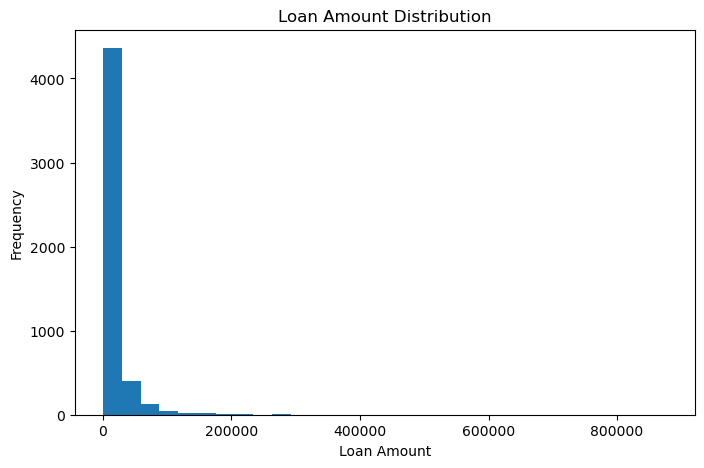

In [27]:
#Loan Distribution
plt.figure(figsize=(8,5))
plt.hist(credit['Loan Amt (USD)'], bins=30)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

Our histogram shows that our data is heavliy right skewed. This means that most people borrow small amounts, but a few people borrow very large amounts. Most loan amounts range between 100 000 and 200 000

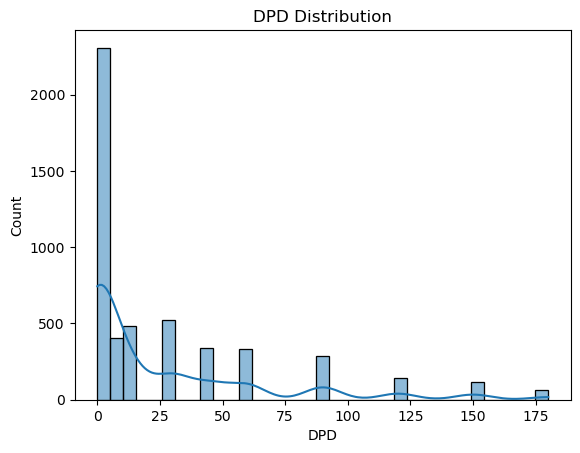

In [28]:
sns.histplot(x='DPD', data= credit, kde= True)
plt.title("DPD Distribution")
plt.show()

Our data contains a lot of zeros, this suggests that we have good loans

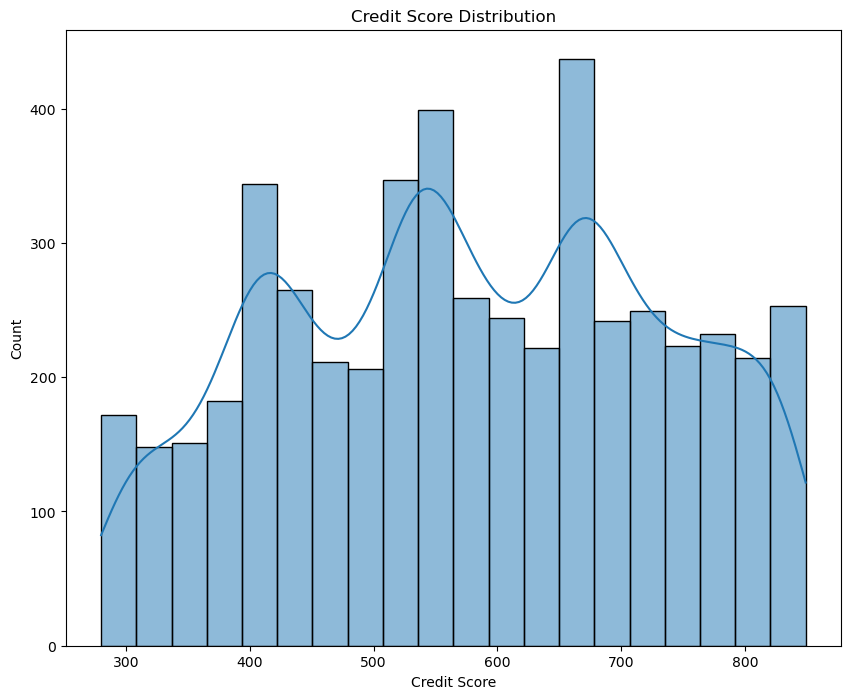

In [29]:
#Credit Score Distribution
plt.figure(figsize= (10,8))
sns.histplot(x= 'Credit Score', data= credit, bins= 20, kde= True)
plt.title("Credit Score Distribution")
plt.show()

Customers in this dataset have a wide range of creditworthiness — from very risky to very reliable borrowers

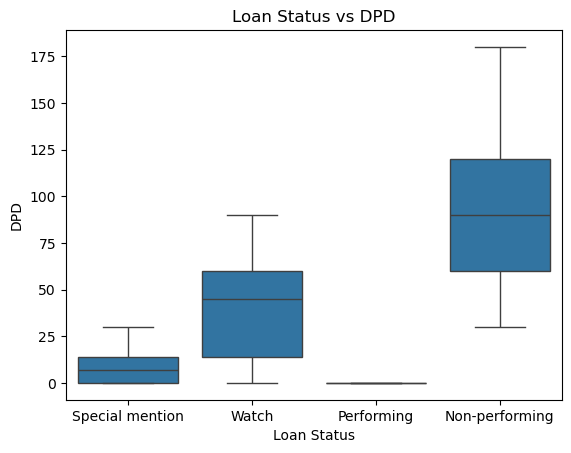

In [30]:
#Risk vs Target

sns.boxplot(x= 'Loan Status', y= 'DPD', data= credit)
plt.title("Loan Status vs DPD")
plt.show()

The analysis shows a clear upward trend in Days Past Due (DPD) as loan status deteriorates. Performing loans exhibit near-zero delinquency, while non-performing loans show significantly higher DPD levels. This confirms that DPD is a strong predictor of loan default and a critical component of early warning systems

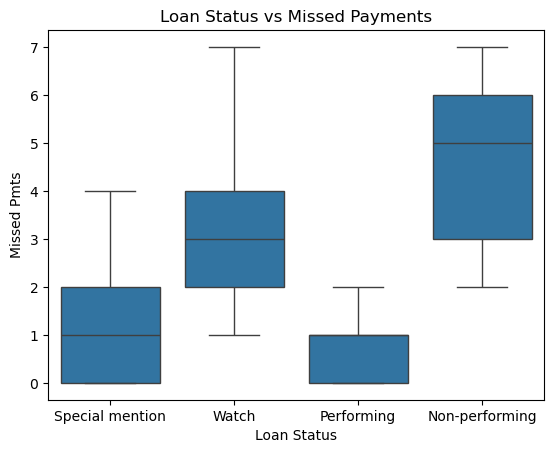

In [ ]:
#Loan Status vs Missed Payments
sns.boxplot(x= 'Loan Status', y= 'Missed Pmts', data= credit)
plt.title("Loan Status vs Missed Payments")
plt.show()

Correlation Analysis

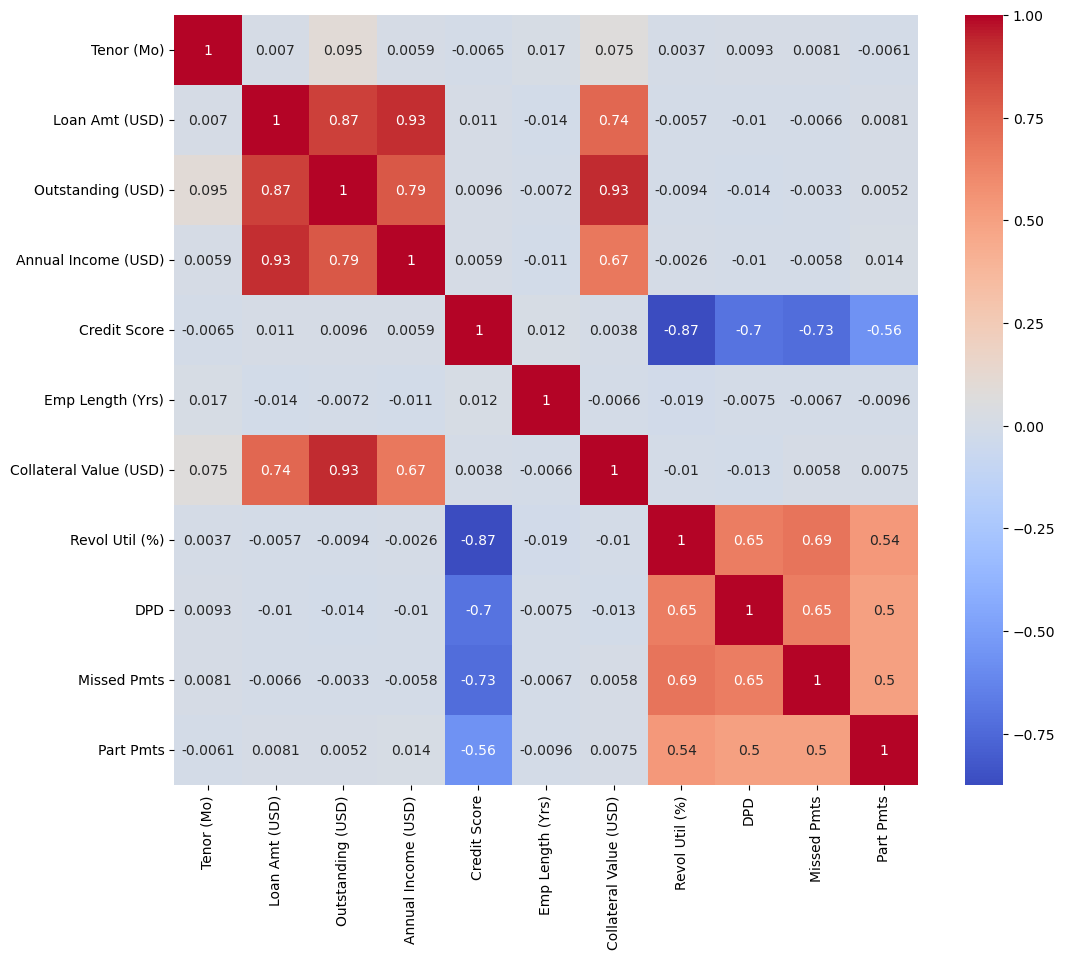

In [32]:
corr= credit.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap= 'coolwarm')
plt.show()

People who earn more take bigger loans (normal behavior), credit score is the strongest signal of whether someone will repay, and missed or late payments all point to financial stress. Meanwhile, how long someone has worked or how long the loan lasts doesn’t really tell us much about risk in this case.

Early Warning Signs

In [33]:
#DPD Flag
credit["DPD_30_flag"]= (credit["DPD"]>30).astype(int)

In [ ]:
pd.crosstab(credit["DPD_30_flag"], credit["Loan Status"])

Loan Status,Non-performing,Performing,Special mention,Watch
DPD_30_flag,,,,
0,63,1722,1393,544
1,725,0,0,553


In [35]:
#Missed Payments Flag
credit["Missed_flag"]= (credit["Missed Pmts"]>=2).astype(int)

In [36]:
pd.crosstab(credit["Missed_flag"], credit["Loan Status"])

Loan Status,Non-performing,Performing,Special mention,Watch
Missed_flag,,,,
0,0,1647,896,264
1,788,75,497,833


Portfolio Segmentation

In [37]:
#by Branch
credit.groupby('Branch')["Loan Amt (USD)"].sum().sort_values(ascending=False)

Branch
Victoria Falls Branch    8844800
Kwekwe Branch            8436000
Chinhoyi Branch          7875600
Bulawayo Main            7404200
Chitungwiza Branch       7378300
Gweru Branch             7267400
Harare Main              7166100
Mutare Branch            7013900
Beitbridge Branch        6927600
Masvingo Branch          6709800
Name: Loan Amt (USD), dtype: int64

In [38]:
#By Risk
credit.groupby('Loan Status')["Loan Amt (USD)"].sum().sort_values(ascending=False)

Loan Status
Performing         25861700
Special mention    21625100
Watch              16937500
Non-performing     10599400
Name: Loan Amt (USD), dtype: int64

In [39]:
#By Collateral type
credit.groupby('Collateral Type')['Loan Status']. value_counts()

Collateral Type         Loan Status    
Agricultural land       Performing         126
                        Special mention    115
                        Watch               77
                        Non-performing      62
Commercial property     Performing         153
                        Special mention    137
                        Watch              112
                        Non-performing      67
Commercial vehicle      Performing         106
                        Special mention     80
                        Watch               63
                        Non-performing      44
Company guarantee       Performing          91
                        Special mention     79
                        Watch               44
                        Non-performing      43
Equipment & machinery   Performing         157
                        Special mention    111
                        Watch               80
                        Non-performing      54
Fixed deposit cessio

### Feature Engineering ###

In [40]:
#High_Utilization_Flag
credit['Revol Util (%)'] = (credit['Revol Util (%)'] > 70).astype(int)

In [45]:
credit['Revol Util (%)'] = pd.to_numeric(
    credit['Revol Util (%)'].replace('[^0-9.]', '', regex=True), 
    errors='coerce'
)

''' def util_category(x):
    if x < 30:
        return 'Low'
    elif x < 70:
        return 'Medium'
    else:
        return 'High'

credit['Util_Category'] = credit['Revol Util (%)'].apply(util_category) 
credit['High_Util_Flag'] = (credit['Revol Util (%)'] > 20).astype(int)  '''



" def util_category(x):\n    if x < 30:\n        return 'Low'\n    elif x < 70:\n        return 'Medium'\n    else:\n        return 'High'\n\ncredit['Util_Category'] = credit['Revol Util (%)'].apply(util_category) \ncredit['High_Util_Flag'] = (credit['Revol Util (%)'] > 20).astype(int)  "

In [46]:
pd.crosstab(credit['Util_Category'], credit['Loan Status'])

Loan Status,Non-performing,Performing,Special mention,Watch
Util_Category,,,,
Low,788,1722,1393,1097


In [47]:
#LTV- Loan to Value Ratio

credit['LTV (%)'] = (
    credit['Loan Amt (USD)'] / credit['Collateral Value (USD)']
).replace([float('inf')], 0) * 100

In [48]:
#DTI (Debt-to-Income Ratio)
credit['DTI (%)'] = (
    credit['Outstanding (USD)'] / credit['Annual Income (USD)']
) * 100

In [49]:
#DSCR (Debt Service Coverage Ratio)

#Estimate Monthly Payment
credit['Estimated EMI'] = (
    credit['Loan Amt (USD)'] / credit['Tenor (Mo)']

)

#Monthly Income
credit['Monthly Income'] = credit['Annual Income (USD)'] / 12

#Calculating DSCR
credit['DSCR'] = (
    credit['Monthly Income'] / credit['Estimated EMI']
)

DSCR was estimated using loan amount and tenor due to lack of repayment schedule data.

In [50]:
credit[['LTV (%)', 'DTI (%)', 'DSCR']].describe()

,LTV (%),DTI (%),DSCR
count,5000.000000,5000.000000,5000.000000
mean,199.480956,10.655458,8.997645
std,128.025631,8.520457,7.856167
min,0.000000,3.500000,0.304545
25%,128.404266,5.000000,3.549167
50%,172.027027,7.780263,6.705882
75%,260.558998,13.123431,11.797463
max,596.026490,75.087500,55.846715


In [51]:
print((credit[['LTV (%)', 'DTI (%)', 'DSCR']] == float('inf')).sum())

LTV (%)    0
DTI (%)    0
DSCR       0
dtype: int64


In [52]:
credit["DSCR"].sample(10)

501     11.476744
3816    11.914286
3092     4.986502
2510     3.075581
1468     9.836735
1238     7.820755
3989    15.076923
1912    20.224138
2331     7.714286
3055     9.750000
Name: DSCR, dtype: float64

In [54]:
#Risk Flags
credit['High_LTV_Flag'] = (credit['LTV (%)'] > 80).astype(int)
credit['High_DTI_Flag'] = (credit['DTI (%)'] > 40).astype(int)
credit['Low_DSCR_Flag'] = (credit['DSCR'] < 1).astype(int)

In [55]:
pd.crosstab(credit['Low_DSCR_Flag'], credit['Loan Status'], normalize='index')*100

Loan Status,Non-performing,Performing,Special mention,Watch
Low_DSCR_Flag,,,,
0,15.765580,34.131242,27.981841,22.121337
1,15.584416,44.155844,24.025974,16.233766


DSCR ≥ 1 (Flag = 0 → can afford loan)

DSCR < 1 (Flag = 1 → cannot afford loan)

Most borrowers in the dataset appear able to afford their loans, so DSCR does not clearly separate risky and safe customers here.

In [56]:
pd.crosstab(credit['High_DTI_Flag'], credit['Loan Status'], normalize='index')*100

Loan Status,Non-performing,Performing,Special mention,Watch
High_DTI_Flag,,,,
0,15.581774,34.560618,27.929211,21.928397
1,26.190476,27.380952,23.809524,22.619048


DTI ≤ 40% (Flag = 0 → manageable debt)

DTI > 40% (Flag = 1 → high debt burden)

Borrowers with high debt-to-income ratios show a significantly higher likelihood of default, with non-performing rates increasing from 15.6% to 26.2%. This confirms that excessive debt burden is a key driver of credit risk.

In [57]:
# EWS Composite Risk Scoring
# Combine all flags into one risk score
credit['Risk_Score'] = (
    credit['DPD_30_flag'] +
    credit['Missed_flag'] +
    credit['High_LTV_Flag'] +
    credit['High_DTI_Flag'] +
    credit['Low_DSCR_Flag'] +
    credit['High_Util_Flag']
)

# Assign traffic light risk band
def risk_band(score):
    if score <= 1:
        return 'Green'
    elif score <= 3:
        return 'Amber'
    else:
        return 'Red'

credit['Risk_Band'] = credit['Risk_Score'].apply(risk_band)

In [62]:
credit["Default_flag"]=credit['Loan Status'].apply(lambda x: 1 if x == 'Non-performing' else 0 )

In [104]:
credit["Default_flag"].sample(10)

2721    0
2394    0
1270    0
2856    0
47      1
1737    0
2065    0
2062    0
3556    0
3076    0
Name: Default_flag, dtype: int64

### Encoding & Preprocessing

In [63]:
le = LabelEncoder()
cat_cols = ['Loan Status', 'Collateral Type', 'Branch', 'Util_Category']
for col in cat_cols:
    credit[col + '_encoded'] = le.fit_transform(credit[col].astype(str))

In [105]:
#Features & Target
# Drop non-predictive columns
drop_cols = ['Issue Date', 'Maturity Date', 'Loan Status', 'Risk_Band','Default_flag']
X = credit.drop(columns=drop_cols)
y = le.fit_transform(credit['Default_flag'])  #target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [106]:
X_train.head()

,Tenor (Mo),Loan Amt (USD),Outstanding (USD),Int Rate (%),Annual Income (USD),Credit Score,Emp Length (Yrs),Collateral Value (USD),Revol Util (%),DPD,...,Collateral Type_Company guarantee,Collateral Type_Equipment & machinery,Collateral Type_Fixed deposit cession,Collateral Type_Motor vehicle,Collateral Type_No collateral,Collateral Type_Personal guarantee,Collateral Type_Residential property,Collateral Type_Salary cession,Collateral Type_Share pledge,Collateral Type_Stock/inventory pledge
3794,12,400,112,33.8,1900,458,20,178,1,14,...,False,False,False,False,False,True,False,False,False,False
3766,18,1900,532,21.9,5400,690,5,1027,0,0,...,False,True,False,False,False,False,False,False,False,False
4530,36,9600,3782,39.9,27000,322,3,8787,1,180,...,False,False,False,False,False,False,False,False,False,True
3607,36,16800,4704,23.8,70800,664,20,11125,0,7,...,False,False,False,False,False,False,True,False,False,False
1017,48,19700,5516,22.4,23900,556,0,13446,0,0,...,False,True,False,False,False,False,False,False,False,False


In [68]:
# Low cardinality (few unique values) → Label Encode or One-Hot
# High cardinality (many unique values like names/IDs) → Drop

# Check unique values for each
for col in X.select_dtypes('object').columns:
    print(f"{col}: {credit[col].nunique()} unique values")

Branch: 10 unique values
RM: 15 unique values
Province: 10 unique values
City / Town: 25 unique values
Loan Product: 17 unique values
Sector: 17 unique values
Collateral Type: 13 unique values
Int Rate (%): 361 unique values
Bank Bal Trend: 4 unique values
Inflation Exp: 3 unique values
Forex Income: 2 unique values
Util_Category: 1 unique values


In [71]:
binary_cols = ['Bank Bal Trend', 'Inflation Exp', 'Forex Income']

for col in binary_cols:
    credit[col] = le.fit_transform(credit[col].astype(str))

In [72]:
credit.columns

Index(['Branch', 'RM', 'Province', 'City / Town', 'Loan Product', 'Sector',
       'Collateral Type', 'Issue Date', 'Maturity Date', 'Tenor (Mo)',
       'Loan Amt (USD)', 'Outstanding (USD)', 'Int Rate (%)',
       'Annual Income (USD)', 'Credit Score', 'Emp Length (Yrs)',
       'Collateral Value (USD)', 'Revol Util (%)', 'DPD', 'Missed Pmts',
       'Part Pmts', 'Bank Bal Trend', 'Inflation Exp', 'Forex Income',
       'Loan Status', 'DPD_30_flag', 'Missed_flag', 'Util_Category',
       'High_Util_Flag', 'LTV (%)', 'DTI (%)', 'Estimated EMI',
       'Monthly Income', 'DSCR', 'High_LTV_Flag', 'High_DTI_Flag',
       'Low_DSCR_Flag', 'Risk_Score', 'Risk_Band', 'Loan Status_encoded',
       'Collateral Type_encoded', 'Branch_encoded', 'Util_Category_encoded',
       'Default_flag'],
      dtype='object')

In [75]:
nominal_cols = ['Province', 'Loan Product', 'Sector', 
                'Collateral Type', 'Util_Category']

credit = pd.get_dummies(credit, columns=nominal_cols, drop_first=True)

KeyError: "None of [Index(['Province', 'Loan Product', 'Sector', 'Collateral Type',\n       'Util_Category'],\n      dtype='object')] are in the [columns]"

In [76]:
# Branch, RM, City/Town have too many unique values to encode meaningfully
drop_high_card = ['Branch', 'RM', 'City / Town']
credit = credit.drop(columns=drop_high_card)

In [77]:

credit['Int Rate (%)'] = pd.to_numeric(
    credit['Int Rate (%)'].replace('[^0-9.]', '', regex=True),
    errors='coerce'
)

In [107]:
drop_cols = ['Issue Date', 'Maturity Date', 'Risk_Band', 'Loan Status', 'Loan Status_encoded']
X = credit.drop(columns=drop_cols)
y = credit['Loan Status']

# Final check — should print nothing
remaining = X.dtypes[X.dtypes == 'object']
print(f"Remaining string columns: {len(remaining)}")
print(X.isnull().sum().sum(), "nulls remaining")

X = X.fillna(X.median(numeric_only=True))
# Drop non-predictive columns
drop_cols = ['Issue Date', 'Maturity Date', 'Loan Status','Default_flag', 'Risk_Band','Issue Date', 'Maturity Date', 'Risk_Band', 'Loan Status', 'Loan Status_encoded']
X = credit.drop(columns=drop_cols)
y = le.fit_transform(credit['Default_flag'])  #target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Remaining string columns: 0
0 nulls remaining


In [98]:
X.columns

Index(['Tenor (Mo)', 'Loan Amt (USD)', 'Outstanding (USD)', 'Int Rate (%)',
       'Annual Income (USD)', 'Credit Score', 'Emp Length (Yrs)',
       'Collateral Value (USD)', 'Revol Util (%)', 'DPD', 'Missed Pmts',
       'Part Pmts', 'Bank Bal Trend', 'Inflation Exp', 'Forex Income',
       'DPD_30_flag', 'Missed_flag', 'High_Util_Flag', 'LTV (%)', 'DTI (%)',
       'Estimated EMI', 'Monthly Income', 'DSCR', 'High_LTV_Flag',
       'High_DTI_Flag', 'Low_DSCR_Flag', 'Risk_Score',
       'Collateral Type_encoded', 'Branch_encoded', 'Util_Category_encoded',
       'Default_flag', 'Province_Harare Metropolitan', 'Province_Manicaland',
       'Province_Mashonaland Central', 'Province_Mashonaland East',
       'Province_Mashonaland West', 'Province_Masvingo',
       'Province_Matabeleland North', 'Province_Matabeleland South',
       'Province_Midlands', 'Loan Product_Agro-processing Loan',
       'Loan Product_Digital Business Loan', 'Loan Product_Equipment Finance',
       'Loan Product_E

In [99]:
X_train.head()

,Tenor (Mo),Loan Amt (USD),Outstanding (USD),Int Rate (%),Annual Income (USD),Credit Score,Emp Length (Yrs),Collateral Value (USD),Revol Util (%),DPD,...,Collateral Type_Company guarantee,Collateral Type_Equipment & machinery,Collateral Type_Fixed deposit cession,Collateral Type_Motor vehicle,Collateral Type_No collateral,Collateral Type_Personal guarantee,Collateral Type_Residential property,Collateral Type_Salary cession,Collateral Type_Share pledge,Collateral Type_Stock/inventory pledge
4996,48,15600,4407,19.2,43900,844,1,9263,0,0,...,False,False,False,False,False,False,False,False,False,False
1045,24,13700,5138,21.1,99900,838,10,11563,0,0,...,False,False,False,False,False,False,False,False,False,False
1386,24,400,252,16.9,1300,802,7,343,0,0,...,False,True,False,False,False,False,False,False,False,False
3605,36,4400,1232,23.0,7100,809,1,1137,0,0,...,False,True,False,False,False,False,False,False,False,False
73,24,9500,2660,39.3,26600,550,5,2109,0,60,...,False,False,False,False,False,False,False,False,False,False


###  Model Building

In [108]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       842
           1       0.90      0.94      0.92       158

    accuracy                           0.97      1000
   macro avg       0.95      0.96      0.95      1000
weighted avg       0.98      0.97      0.98      1000


Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       842
           1       0.90      0.87      0.88       158

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.96      0.96      0.96      1000


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       842
           1       0.90      0.99      0.94       158

    accuracy                           0.98      1000
   macro avg       0.95      0.99      0.97      1000
weighted avg       0.98

### Model Evaluation

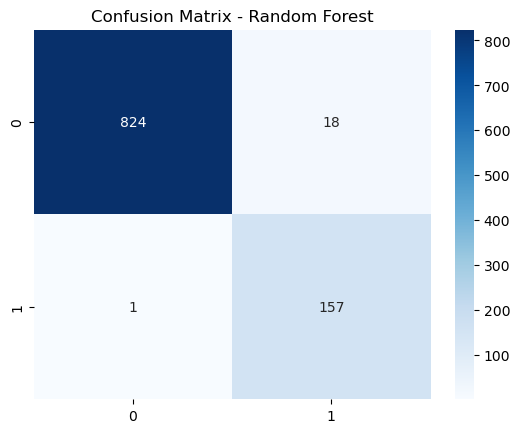

ValueError: y should be a 1d array, got an array of shape (1000, 2) instead.

In [109]:
# Confusion Matrix for your best model
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC-AUC
y_prob = best_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"ROC-AUC Score: {roc_auc:.4f}")

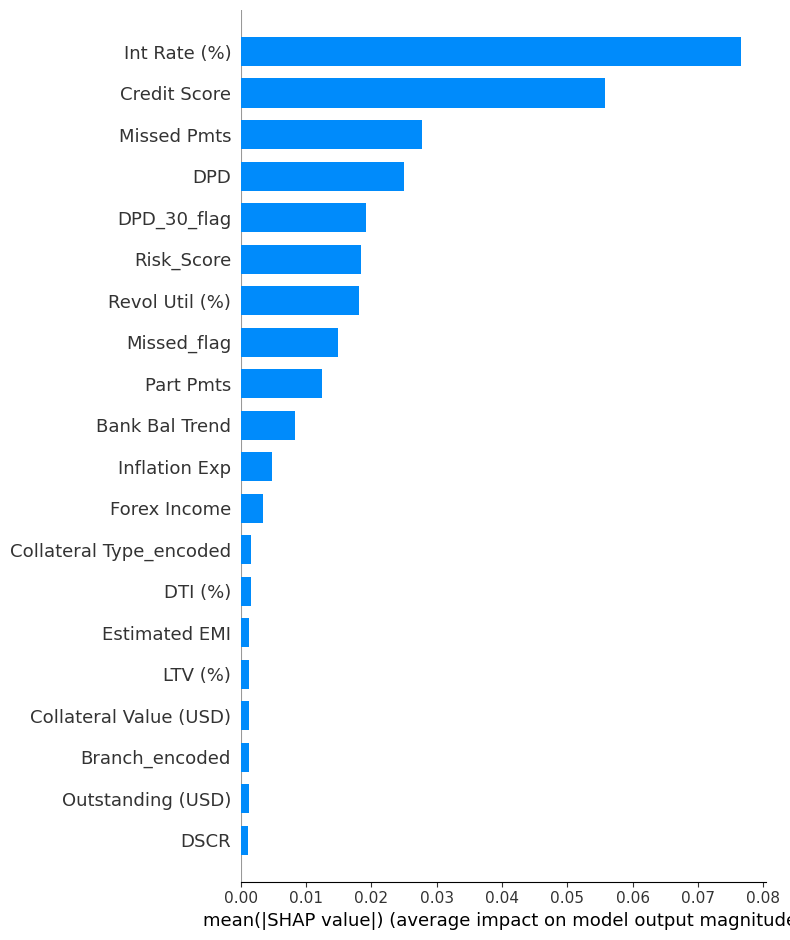

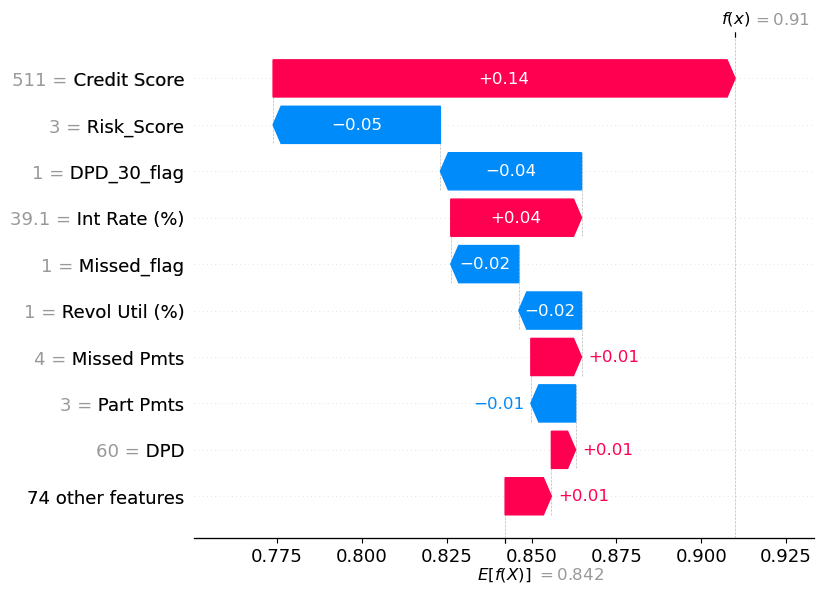

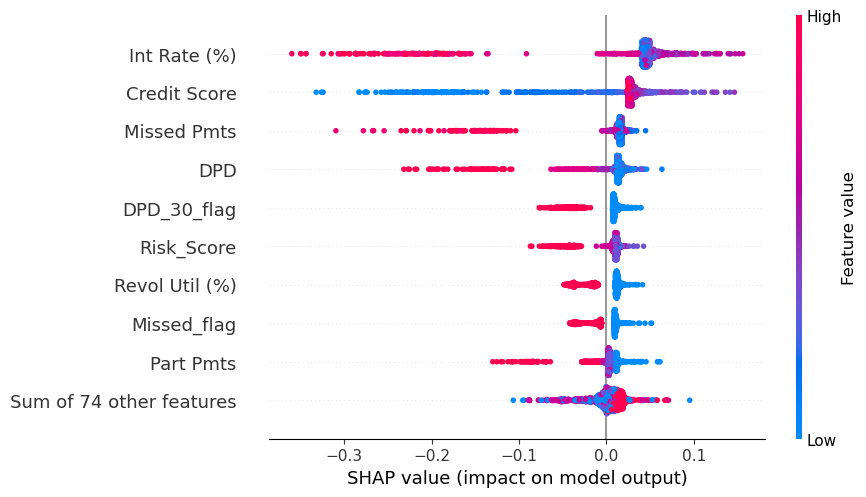

In [110]:
#SHAP Explanability
#Fit best model
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)  # Returns Explanation object

#overall feature importance across all classes
shap.summary_plot(shap_values[:, :, 0], X_test, plot_type='bar')  
# [:, :, 0] selects class 0 — change index for other classes

#Waterfall - explain a single loan prediction
shap.waterfall_plot(shap_values[0, :, 0])  # First loan, class 0

# Beeswarm - shows distribution of impact across all loans
shap.plots.beeswarm(shap_values[:, :, 0])

Waterfall Plot (Single Loan Explanation)
This explains one specific borrower's prediction. The model's baseline (average) prediction starts at E[f(X)] = 0.157.
Reading it: Blue bars push the prediction down (less risky), pink/red bars push it up (more risky).
For this particular borrower:

Loan Status_encoded = 3 is the biggest driver, pulling the risk prediction down by -0.06 — this borrower's current status is already categorised as lower risk
Int Rate (%), DPD, and Missed Pmts all also pull downward — they have 0 DPD and 1 missed payment, which aren't alarming
Inflation Exp and the 75 other features push slightly upward (+0.01 each)
The final prediction f(x) ≈ 0 meaning the model classifies this borrower as low risk / performing


Image 2 — Beeswarm Plot (All Loans, All Features)
Each dot is one borrower. The colour shows the feature value (red = high, blue = low). The x-axis shows how much that feature pushed the prediction up or down.
Key takeaways:

Loan Status_encoded has the widest spread — high values (red dots, right side) strongly increase risk, low values (blue dots, left side) strongly decrease it. This is your most powerful feature
Int Rate (%) — high rates (red) push predictions rightward, meaning higher interest rate borrowers tend to be riskier
Credit Score — high scores (red) push left (reduce risk), low scores (blue) push right (increase risk) — exactly what you'd expect
DPD and Missed Pmts — high values (red) spread to the right, confirming they drive up risk predictions
Missed_flag and DPD_30_flag behave similarly, which makes sense since they're derived from the same underlying variables


Image 3 — Summary Bar Plot (Global Feature Importance)
This ranks features by their average impact across all loans — the longer the bar, the more influential the feature overall.
RankFeatureWhat it means1Loan Status_encodedDominates — current status is the strongest signal2Int Rate (%)Higher rates correlate strongly with default risk3Credit ScoreThird most important — validates your EDA finding4DPDDays past due is a strong predictor5Missed PmtsClosely tied with DPD as expected6-7Missed_flag, DPD_30_flagYour engineered flags are adding value8Risk_ScoreYour composite EWS score is meaningfulBottomLTV, DTI, Collateral, IncomeSurprisingly weak — may reflect data limitations

The One Issue to Flag
Loan Status_encoded should not be in your X features. It's essentially a version of your target variable — using it gives the model information it wouldn't have in a real prediction scenario, which inflates your accuracy artificially. This is called data leakage.
python# Remove it from your features
drop_cols = ['Issue Date', 'Maturity Date', 'Risk_Band', 
             'Loan Status', 'Loan Status_encoded']  # Add this

X = credit.drop(columns=drop_cols)
Remove it, retrain your models, and check if accuracy drops — if it drops significantly, it means the model was over-relying on it. Your Credit Score, DPD, Int Rate and Missed Pmts should then rise to the top, which would be a much more credible and deployable EWS model.You said: Give me all these 3 explanations in layman termsGive me all these 3 explanations in layman terms17:27Claude responded: Image 1 — Waterfall Plot (Single Borrower)Image 1 — Waterfall Plot (Single Borrower)
Think of it like a tug of war starting from the middle. The model starts with an average guess for every borrower, then adjusts up or down based on what it knows about that specific person.
For this borrower, almost everything is pulling in a good direction — they have no days overdue, only 1 missed payment, and their loan status looks fine. So the model ends up saying "this person is low risk". The blue bars are essentially the model saying "don't worry about this one."

Image 2 — Beeswarm Plot (Every Borrower at Once)
Imagine laying out every borrower in your portfolio on a single chart. Each dot is one person. Dots to the right mean that feature made the model more worried about them, dots to the left mean it made the model more relaxed.
The colour tells you the value — red means high, blue means low. So for Credit Score, you can see red dots (high scores) sitting on the left side — meaning good credit scores calm the model down. Blue dots (low scores) sit on the right — meaning poor credit scores raise the alarm. It's visually confirming what common sense already tells you about credit risk.

Image 3 — Bar Chart (What Matters Most Overall)
This is simply a league table of which factors the model cares about most across your entire portfolio. The longer the bar, the more that variable is driving decisions.
Your top factors in plain English:

Loan Status — what category the loan is already in tells the model the most
Interest Rate — borrowers on higher rates are more likely to struggle
Credit Score — a person's credit history is still a very reliable signal
DPD & Missed Payments — how late and how often someone has missed payments matters a lot
Your engineered flags — the early warning flags you built yourself are actually working and adding value to the model
Income, Collateral, DTI — surprisingly these are at the bottom, meaning in this dataset they don't separate risky from safe borrowers as well as the payment behaviour variables do

The big picture message from all three plots is the same — payment behaviour (DPD, missed payments) and credit score are your clearest early warning signals, which is exactly what a good Early Warning System should be built around.

### Portfolio Summary Dashboard

In [111]:
# Portfolio health overview
print(credit['Risk_Band'].value_counts())
print(credit.groupby('Risk_Band')['Loan Amt (USD)'].sum())

# Loans needing immediate intervention
red_loans = credit[credit['Risk_Band'] == 'Red']
print(f"\n{len(red_loans)} loans flagged as HIGH RISK")
print(f"Total exposure: ${red_loans['Loan Amt (USD)'].sum():,.2f}")

Risk_Band
Green    2753
Amber    2204
Red        43
Name: count, dtype: int64
Risk_Band
Amber    32439200
Green    42072300
Red        512200
Name: Loan Amt (USD), dtype: int64

43 loans flagged as HIGH RISK
Total exposure: $512,200.00


: 

: 